In [15]:
from PIL import Image
from torchvision import transforms
import torch
import torch.nn.functional as F

transform = transforms.Compose(
    [
        transforms.Resize((448, 448), interpolation=Image.BICUBIC),
        transforms.ToTensor(),
    ]
)
# prompt_raw = "the {object} is {state}"
drawer_prompt_ensemble = [
    "the wooden {object} under the table is {state}",
    "the brown {object} below the table is {state}",
    "the {object} beneath the table is {state}",
]
entity_state_map = {
    "drawer": ["open", "closed"],
}
images = []
solutions = []
prompts_per_image = []
for entity, states in entity_state_map.items():
    for state in states:
        for i in range(10):
            dir = f"../data/samples/front"
            image = Image.open(f"{dir}/{entity}_{state}_{i}.png")
            images.append(image)
            solutions.append(state)

In [26]:
open_prompts = [
    tmpl.format(object="drawer", state="open")
    for tmpl in drawer_prompt_ensemble
]
closed_prompts = [
    tmpl.format(object="drawer", state="closed")
    for tmpl in drawer_prompt_ensemble
]
open_prompts = ["the drawer is open"]  # --- IGNORE ---
closed_prompts = ["the drawer is closed"]  # --- IGNORE ---

In [17]:
from transformers import AutoModel

model= AutoModel.from_pretrained("google/tipsv2-b14", trust_remote_code=True)
model.eval()

Loading weights:   0%|          | 0/323 [00:00<?, ?it/s]

TIPSv2Model(
  (vision_encoder): VisionTransformer(
    (patch_embed): PatchEmbed(
      (proj): Conv2d(3, 768, kernel_size=(14, 14), stride=(14, 14))
      (norm): Identity()
    )
    (blocks): ModuleList(
      (0-11): 12 x Block(
        (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (attn): MemEffAttention(
          (qkv): Linear(in_features=768, out_features=2304, bias=True)
          (attn_drop): Dropout(p=0.0, inplace=False)
          (proj): Linear(in_features=768, out_features=768, bias=True)
          (proj_drop): Dropout(p=0.0, inplace=False)
        )
        (ls1): LayerScale()
        (drop_path1): Identity()
        (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): Mlp(
          (fc1): Linear(in_features=768, out_features=3072, bias=True)
          (act): GELU(approximate='none')
          (fc2): Linear(in_features=3072, out_features=768, bias=True)
          (drop): Dropout(p=0.0, inplace=False)
        )
        (l

In [28]:
# encode ONCE
open_embs = F.normalize(model.encode_text(open_prompts), dim=-1)

closed_embs = F.normalize(model.encode_text(closed_prompts), dim=-1)


open_proto = F.normalize(open_embs.mean(0), dim=-1)
closed_proto = F.normalize(closed_embs.mean(0), dim=-1)

cos_sim =open_proto @ closed_proto.T
print(f"Cosine similarity between open and closed prototypes: {cos_sim.item():.4f}")


Cosine similarity between open and closed prototypes: 0.9723


/tmp/ipykernel_3169090/3768945397.py:10: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3683.)
  cos_sim =open_proto @ closed_proto.T


In [19]:
pixel_values = torch.stack(
    [
        transform(img)       for img in images
    
    ]
)

out = model.encode_image(pixel_values)
print(out.cls_token.shape)  # (1, 1, 768) — global image embedding
print(out.patch_tokens.shape)  # (1, 1024, 768) — per-patch spatial features
print(out.cls_token)  # (1, 768) — mean-pooled patch features

torch.Size([20, 1, 768])
torch.Size([20, 1024, 768])


In [23]:
print(out.cls_token)

tensor([[[ 0.2999,  0.0905,  0.0103,  ...,  0.0015,  0.2481,  0.1010]],

        [[ 0.3018,  0.0641,  0.0336,  ...,  0.0062,  0.2227,  0.1264]],

        [[ 0.3024,  0.0910,  0.0149,  ...,  0.0083,  0.2372,  0.1340]],

        ...,

        [[ 0.2965,  0.1485, -0.0397,  ...,  0.0361,  0.2063,  0.0927]],

        [[ 0.2989,  0.1015, -0.0117,  ..., -0.0183,  0.2001,  0.1420]],

        [[ 0.2983,  0.0994,  0.0047,  ..., -0.0102,  0.2047,  0.1140]]])


In [20]:
img_embs = F.normalize(out.cls_token[:, 0, :], dim=-1)

In [24]:
print(img_embs.shape)  # (num_images, 768)
print(img_embs)

torch.Size([20, 768])
tensor([[ 0.0458,  0.0138,  0.0016,  ...,  0.0002,  0.0378,  0.0154],
        [ 0.0461,  0.0098,  0.0051,  ...,  0.0009,  0.0340,  0.0193],
        [ 0.0462,  0.0139,  0.0023,  ...,  0.0013,  0.0362,  0.0205],
        ...,
        [ 0.0455,  0.0228, -0.0061,  ...,  0.0055,  0.0317,  0.0142],
        [ 0.0461,  0.0156, -0.0018,  ..., -0.0028,  0.0308,  0.0219],
        [ 0.0456,  0.0152,  0.0007,  ..., -0.0016,  0.0313,  0.0174]])


In [29]:
open_scores = img_embs @ open_proto
closed_scores = img_embs @ closed_proto
scores = torch.stack([open_scores, closed_scores], dim=1)
pred = scores.argmax(dim=1)
probs = F.softmax(scores, dim=1)
print(scores)
print(pred)
print(probs)

tensor([[0.1513, 0.1484],
        [0.1555, 0.1522],
        [0.1554, 0.1521],
        [0.1559, 0.1527],
        [0.1504, 0.1480],
        [0.1558, 0.1532],
        [0.1512, 0.1478],
        [0.1531, 0.1499],
        [0.1538, 0.1496],
        [0.1529, 0.1495],
        [0.1471, 0.1465],
        [0.1461, 0.1450],
        [0.1494, 0.1490],
        [0.1436, 0.1427],
        [0.1464, 0.1464],
        [0.1445, 0.1444],
        [0.1495, 0.1471],
        [0.1470, 0.1449],
        [0.1467, 0.1461],
        [0.1436, 0.1430]])
tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
tensor([[0.5007, 0.4993],
        [0.5008, 0.4992],
        [0.5008, 0.4992],
        [0.5008, 0.4992],
        [0.5006, 0.4994],
        [0.5006, 0.4994],
        [0.5009, 0.4991],
        [0.5008, 0.4992],
        [0.5010, 0.4990],
        [0.5008, 0.4992],
        [0.5002, 0.4998],
        [0.5003, 0.4997],
        [0.5001, 0.4999],
        [0.5002, 0.4998],
        [0.5000, 0.5000],
        [0.5000, 0.5

0.5007227063179016
0.5008240342140198
0.5008265376091003
0.5008081793785095
0.5006098747253418
0.5006312131881714
0.500853419303894
0.5007973909378052
0.5010407567024231
0.5008376836776733
0.5001583695411682
0.5002868175506592
0.5001019239425659
0.5002366900444031
0.5000064969062805
0.5000144839286804
0.5005987882614136
0.5005239844322205
0.5001494884490967
0.5001639723777771


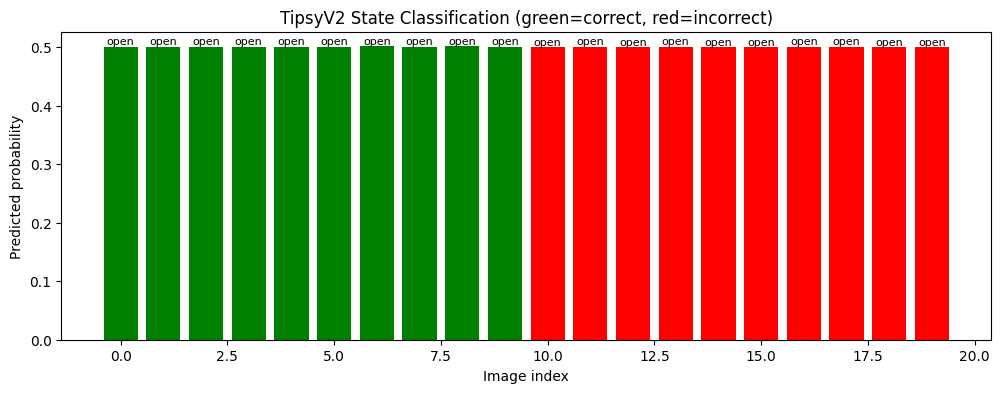

In [32]:
import matplotlib.pyplot as plt

# Get predicted state for each image
pred_indices = probs.argmax(dim=1).tolist()
state_labels = ["open", "closed"]  # order must match prompt

correct = [state_labels[pred] == gt for pred, gt in zip(pred_indices, solutions)]

plt.figure(figsize=(12, 4))
for i, (prob, gt, is_correct, pred_idx) in enumerate(
    zip(probs, solutions, correct, pred_indices)
):
    pred_label = state_labels[pred_idx]
    color = "green" if is_correct else "red"
    plt.bar(i, prob[pred_idx].item(), color=color)
    print(prob[pred_idx].item())
    plt.text(
        i, prob[pred_idx].item(), f"{pred_label}", ha="center", va="bottom", fontsize=8
    )
plt.xlabel("Image index")
plt.ylabel("Predicted probability")
plt.title("TipsyV2 State Classification (green=correct, red=incorrect)")
plt.show()

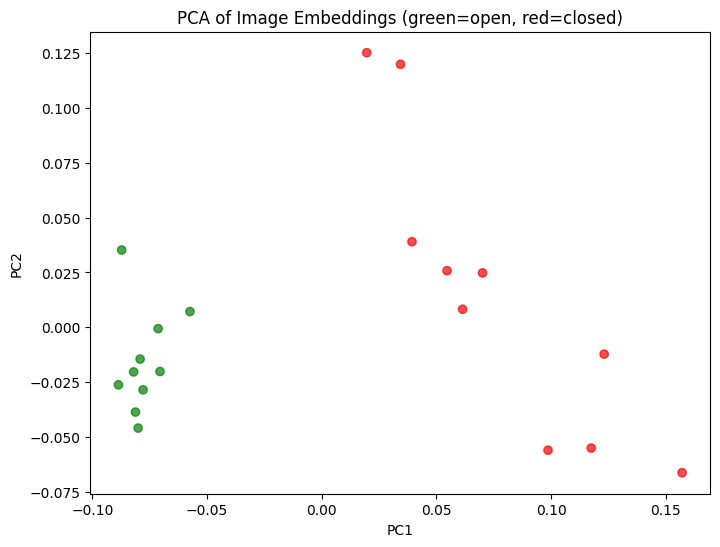

In [30]:
# Visualize image embeddings with PCA
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import numpy as np

# Make sure img_embs and solutions are available from previous cells
# solutions should be a list of "open"/"closed" strings

# Convert solutions to colors
colors = ["green" if s == "open" else "red" for s in solutions]

# Reduce to 2D with PCA
pca = PCA(n_components=2)
img_embs_2d = pca.fit_transform(img_embs.cpu().numpy())

plt.figure(figsize=(8, 6))
plt.scatter(img_embs_2d[:, 0], img_embs_2d[:, 1], c=colors, alpha=0.7)
plt.title("PCA of Image Embeddings (green=open, red=closed)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()